# **1. Configuración general e importación de librerías**

Este primer bloque prepara el entorno de trabajo. Se importan las librerías necesarias para manipulación de datos, construcción del Random Forest, evaluación de individuos y ejecución del algoritmo genético. También se monta Google Drive y se fijan los principales parámetros del experimento.

Aquí puedes modificar fácilmente el número de tickets, tamaño de población, generaciones, probabilidades de cruce/mutación y pesos de las penalizaciones.

In [6]:
# ============================================================
# 1. CONFIGURACIÓN GENERAL
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
import random
import math
import time
import copy

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor


# ------------------------------------------------------------
# SEMILLA
# ------------------------------------------------------------

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# ------------------------------------------------------------
# ARCHIVO
# ------------------------------------------------------------

CSV_PATH = "/content/drive/MyDrive/tickets_para_optimizacion.csv"


# ------------------------------------------------------------
# PARÁMETROS DEL PROBLEMA
# ------------------------------------------------------------

N_TICKETS = 200

DEFAULT_CAPACITY_HOURS = 40.0

SLA_BY_PRIORITY = {
    "1": 8.0,
    "2": 16.0,
    "3": 24.0,
    "4": 40.0
}

MIN_PRIORITY_HISTORY = 1

BETA_BALANCE = 1.0


# ------------------------------------------------------------
# PARÁMETROS DEL ALGORITMO GENÉTICO
# ------------------------------------------------------------

POPULATION_SIZE = 200

MAX_GENERATIONS = 500

TOURNAMENT_SIZE = 3

CROSSOVER_PROB = 0.85

# 1 / n se calculará posteriormente
MUTATION_PROB = None

ELITE_RATE = 0.025

NO_IMPROVEMENT_LIMIT = 50


# ------------------------------------------------------------
# PESOS DE PENALIZACIÓN
# ------------------------------------------------------------

LAMBDA_TEAM = 1000.0

LAMBDA_CAPACITY = 200.0

LAMBDA_SLA = 50.0

LAMBDA_PRIORITY = 20.0


print("Configuración cargada correctamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Configuración cargada correctamente.


# **2. Lectura y preparación de la base**

Este bloque carga el CSV y realiza únicamente el preprocesado necesario para el AG. Se comprueba que existan las variables fundamentales, se convierten las horas a formato numérico y se eliminan observaciones sin información esencial o con horas de trabajo no positivas.

No volvemos a realizar PCA ni el preprocesado multivariante del TFM porque el archivo tickets_para_optimizacion.csv ya procede de ese flujo anterior.

In [7]:
# ============================================================
# 2. LECTURA Y PREPARACIÓN DE LOS DATOS
# ============================================================

df_raw = pd.read_csv(
    CSV_PATH,
    keep_default_na=False
)

print(
    "Dimensiones originales:",
    df_raw.shape
)


required_columns = [
    "Issue key",
    "Assignee",
    "Team",
    "Priority",
    "Worked hours"
]


missing_columns = [
    col
    for col in required_columns
    if col not in df_raw.columns
]


if missing_columns:

    raise ValueError(
        f"Faltan columnas obligatorias: "
        f"{missing_columns}"
    )


df = df_raw.copy()


# ------------------------------------------------------------
# NORMALIZACIÓN DE TEXTO
# ------------------------------------------------------------

text_columns = [
    "Issue key",
    "Assignee",
    "Team",
    "Priority",
    "Issue Type",
    "Request Type"
]


for col in text_columns:

    if col in df.columns:

        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
        )


# ------------------------------------------------------------
# HORAS TRABAJADAS
# ------------------------------------------------------------

df["Worked hours"] = pd.to_numeric(
    df["Worked hours"],
    errors="coerce"
)


# ------------------------------------------------------------
# ELIMINAR REGISTROS NO UTILIZABLES
# ------------------------------------------------------------

df = df[
    df["Assignee"].notna()
    & (df["Assignee"] != "")
    & df["Priority"].notna()
    & (df["Priority"] != "")
    & df["Worked hours"].notna()
    & (df["Worked hours"] > 0)
].copy()


df.reset_index(
    drop=True,
    inplace=True
)


print(
    "Dimensiones después de preparación:",
    df.shape
)

print(
    "Empleados únicos:",
    df["Assignee"].nunique()
)

print(
    "Equipos:",
    sorted(df["Team"].unique())
)

print(
    "Prioridades:",
    sorted(df["Priority"].unique())
)

Dimensiones originales: (9328, 19)
Dimensiones después de preparación: (9326, 19)
Empleados únicos: 40
Equipos: ['BCFIN', 'CRM', 'CS', 'DATA', 'DW', 'IT', 'SEC']
Prioridades: ['P1', 'P2', 'P3', 'P4']


# **3. Selección de los tickets que se optimizarán**

Qué hace esta sección

Aquí seleccionamos la instancia concreta del problema. Los N_TICKETS se extraen aleatoriamente utilizando la semilla 42.

Hay una mejora metodológica importante respecto a algunas primeras versiones de tu COP: estos tickets se eliminan del conjunto utilizado para entrenar el Random Forest.

De este modo:

Tickets del AG∩Entrenamiento RF=∅

y evitamos que el modelo haya memorizado precisamente las observaciones que luego utilizará como instancia de optimización.

In [8]:
# ============================================================
# 3. CREACIÓN DE LA INSTANCIA DE OPTIMIZACIÓN
# ============================================================

if N_TICKETS > len(df):

    raise ValueError(
        "N_TICKETS es superior al número "
        "de observaciones disponibles."
    )


optimization_df = df.sample(
    n=N_TICKETS,
    random_state=RANDOM_SEED
).copy()


training_df = df.drop(
    index=optimization_df.index
).copy()


optimization_df.reset_index(
    drop=True,
    inplace=True
)

training_df.reset_index(
    drop=True,
    inplace=True
)


print(
    "Tickets para optimización:",
    len(optimization_df)
)

print(
    "Tickets para entrenamiento RF:",
    len(training_df)
)

Tickets para optimización: 200
Tickets para entrenamiento RF: 9126


# 4. Identificación de empleados y equipos

Qué hace esta sección

En esta etapa se construye el conjunto de recursos E. Para cada empleado se determina su equipo histórico predominante.

Esto nos permitirá posteriormente comprobar:

Team
i
	​

=Team
j
	​


y penalizar una asignación cuando el empleado seleccionado no pertenece al equipo correspondiente.

In [9]:
# ============================================================
# 4. EMPLEADOS Y EQUIPOS
# ============================================================

employee_team_series = (
    training_df
    .groupby("Assignee")["Team"]
    .agg(
        lambda x: x.mode().iloc[0]
        if len(x.mode()) > 0
        else x.iloc[0]
    )
)


employees = sorted(
    employee_team_series.index.tolist()
)


employee_to_idx = {
    employee: idx
    for idx, employee
    in enumerate(employees)
}


idx_to_employee = {
    idx: employee
    for employee, idx
    in employee_to_idx.items()
}


employee_team = {
    employee: employee_team_series.loc[employee]
    for employee in employees
}


n_employees = len(employees)


print(
    "Número de empleados disponibles:",
    n_employees
)


for employee in employees[:10]:

    print(
        employee,
        "→",
        employee_team[employee]
    )

Número de empleados disponibles: 40
Andre Velicev → CS
Andy Van Puyvelde → BCFIN
Anthony Restiau → CS
Anthony Roels → CS
Ayoub Azzouz → CRM
Bart Jansen → BCFIN
Bjorn Van Cotthem → DW
Camila Reis → CS
Carolina Vaeza → BCFIN
Christophe Kokken → CS


# 5. Construcción de la elegibilidad histórica por prioridad

Qué hace esta sección

El AG necesita conocer qué empleados han demostrado históricamente experiencia con cada prioridad.

A diferencia del COP, en el AG un valor 0 no prohibirá obligatoriamente la asignación. Generará una penalización.

In [10]:
# ============================================================
# 5. HISTÓRICO DE PRIORIDAD
# ============================================================

priority_history = (
    training_df
    .groupby(
        ["Assignee", "Priority"]
    )
    .size()
    .to_dict()
)


def has_priority_history(
    employee,
    priority
):

    count = priority_history.get(
        (employee, priority),
        0
    )

    return (
        count >= MIN_PRIORITY_HISTORY
    )


print(
    "Histórico de prioridad preparado."
)

Histórico de prioridad preparado.


# 6. Entrenamiento del Random Forest para tij

Qué hace esta sección

Esta sección estima el parámetro central de ambos modelos:

t
ij
	​

que representa el tiempo esperado de resolución del ticket i cuando es asignado al empleado j.

El RF utiliza como variable objetivo:

Worked hours

y utiliza, cuando están disponibles, prioridad, empleado, equipo, tipo de incidencia, tipo de solicitud y las variables estructurales del ticket.

Los parámetros principales son los mismos que planteamos anteriormente:

n
trees =300

y: min_samples_leaf=2

In [11]:
# ============================================================
# 6. RANDOM FOREST PARA ESTIMAR t_ij
# ============================================================

candidate_features = [
    "Priority",
    "Assignee",
    "Team",
    "Issue Type",
    "Request Type",
    "Inward Tickets",
    "Outward Tickets",
    "Inward Project",
    "Outward Project",
    "Inward",
    "Outward",
    "Total Link"
]


features = [
    col
    for col in candidate_features
    if col in training_df.columns
]


categorical_features = [
    col
    for col in features
    if training_df[col].dtype == "object"
]


numeric_features = [
    col
    for col in features
    if col not in categorical_features
]


# ------------------------------------------------------------
# CONVERSIÓN DE NUMÉRICAS
# ------------------------------------------------------------

for col in numeric_features:

    training_df[col] = pd.to_numeric(
        training_df[col],
        errors="coerce"
    )

    optimization_df[col] = pd.to_numeric(
        optimization_df[col],
        errors="coerce"
    )

    median_value = training_df[col].median()

    training_df[col] = (
        training_df[col]
        .fillna(median_value)
    )

    optimization_df[col] = (
        optimization_df[col]
        .fillna(median_value)
    )


# ------------------------------------------------------------
# TRANSFORMADOR
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)


# ------------------------------------------------------------
# RANDOM FOREST
# ------------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=-1
)


time_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            rf_model
        )
    ]
)


time_model.fit(
    training_df[features],
    training_df["Worked hours"]
)


print(
    "Random Forest entrenado correctamente."
)

Random Forest entrenado correctamente.


# 7. Construcción de la matriz T=(tij)
Qué hace esta sección

Una vez entrenado el RF, generamos una predicción para cada combinación ticket-empleado.

In [12]:
# ============================================================
# 7. MATRIZ DE TIEMPOS t_ij
# ============================================================

n_tickets = len(
    optimization_df
)


processing_time = np.zeros(
    (
        n_tickets,
        n_employees
    ),
    dtype=float
)


for i in range(n_tickets):

    ticket = (
        optimization_df
        .iloc[[i]]
        .copy()
    )


    repeated = pd.concat(
        [ticket] * n_employees,
        ignore_index=True
    )


    repeated["Assignee"] = employees


    if "Team" in features:

        repeated["Team"] = [
            employee_team[employee]
            for employee in employees
        ]


    predictions = (
        time_model.predict(
            repeated[features]
        )
    )


    processing_time[i, :] = (
        np.maximum(
            predictions,
            0.01
        )
    )


print(
    "Matriz t_ij creada:",
    processing_time.shape
)


print(
    "Tiempo mínimo estimado:",
    processing_time.min()
)

print(
    "Tiempo máximo estimado:",
    processing_time.max()
)

Matriz t_ij creada: (200, 40)
Tiempo mínimo estimado: 0.5826447493167322
Tiempo máximo estimado: 190.87159059564286


# 8. Preparación de SLA, equipos y capacidades
Qué hace esta sección

Ahora convertimos los datos de cada ticket y empleado en estructuras rápidas que utilizará el algoritmo genético.

Cada empleado dispone inicialmente de:

C
j =40h

y cada ticket recibe su SLA en función de prioridad

In [13]:
# ============================================================
# 8. PARÁMETROS OPERATIVOS
# ============================================================

ticket_ids = (
    optimization_df[
        "Issue key"
    ]
    .astype(str)
    .tolist()
)


ticket_priority = (
    optimization_df[
        "Priority"
    ]
    .astype(str)
    .tolist()
)


ticket_team = (
    optimization_df[
        "Team"
    ]
    .astype(str)
    .tolist()
)


employee_capacity = np.full(
    n_employees,
    DEFAULT_CAPACITY_HOURS,
    dtype=float
)


sla = np.array(
    [
        SLA_BY_PRIORITY.get(
            priority,
            np.inf
        )
        for priority
        in ticket_priority
    ],
    dtype=float
)


# ------------------------------------------------------------
# MATRIZ PRIORITY_OK
# ------------------------------------------------------------

priority_ok = np.zeros(
    (
        n_tickets,
        n_employees
    ),
    dtype=bool
)


# ------------------------------------------------------------
# MATRIZ TEAM_OK
# ------------------------------------------------------------

team_ok = np.zeros(
    (
        n_tickets,
        n_employees
    ),
    dtype=bool
)


for i in range(n_tickets):

    for j, employee in enumerate(
        employees
    ):

        priority_ok[i, j] = (
            has_priority_history(
                employee,
                ticket_priority[i]
            )
        )

        team_ok[i, j] = (
            employee_team[employee]
            == ticket_team[i]
        )


print(
    "Parámetros operativos preparados."
)

Parámetros operativos preparados.


9. Probabilidad de mutación y elitismo
Qué hace esta sección

Aquí aplicamos las fórmulas que definimos anteriormente.

La mutación depende directamente del número de tickets:

P
m =
n
1
	​


Mientras que el elitismo depende del tamaño de población:

N
elite =2.5%×N
pop
	​


In [14]:
# ============================================================
# 9. MUTACIÓN Y ELITISMO
# ============================================================

MUTATION_PROB = (
    1.0 / n_tickets
)


N_ELITE = max(
    1,
    int(
        round(
            POPULATION_SIZE
            * ELITE_RATE
        )
    )
)


print(
    "Probabilidad de mutación:",
    MUTATION_PROB
)

print(
    "Individuos élite:",
    N_ELITE
)

Probabilidad de mutación: 0.005
Individuos élite: 5


# 10. Generación de la población inicial
Qué hace esta sección

La población inicial combina tres estrategias:

soluciones aleatorias;
soluciones guiadas hacia empleados rápidos;
soluciones guiadas hacia empleados con menor carga.


Además, se priorizan empleados del mismo equipo y con experiencia histórica en la prioridad correspondiente.

Esto evita que el AG empiece únicamente con soluciones completamente aleatorias de muy baja calidad.

In [15]:
# ============================================================
# 10. GENERACIÓN DE LA POBLACIÓN INICIAL
# ============================================================

def preferred_candidates(i):

    candidates = [
        j
        for j in range(n_employees)
        if (
            team_ok[i, j]
            and priority_ok[i, j]
        )
    ]


    # Fallback: mismo equipo
    if not candidates:

        candidates = [
            j
            for j in range(n_employees)
            if team_ok[i, j]
        ]


    # Fallback final
    if not candidates:

        candidates = list(
            range(n_employees)
        )


    return candidates


def create_random_individual():

    individual = []

    for i in range(n_tickets):

        candidates = (
            preferred_candidates(i)
        )

        individual.append(
            random.choice(candidates)
        )

    return np.array(
        individual,
        dtype=int
    )


def create_fast_individual():

    individual = []

    for i in range(n_tickets):

        candidates = (
            preferred_candidates(i)
        )

        best_j = min(
            candidates,
            key=lambda j:
            processing_time[i, j]
        )

        individual.append(
            best_j
        )

    return np.array(
        individual,
        dtype=int
    )


def create_balanced_individual():

    individual = []

    loads = np.zeros(
        n_employees
    )


    for i in range(n_tickets):

        candidates = (
            preferred_candidates(i)
        )


        best_j = min(
            candidates,
            key=lambda j:
            loads[j]
            + processing_time[i, j]
        )


        individual.append(
            best_j
        )


        loads[best_j] += (
            processing_time[i, best_j]
        )


    return np.array(
        individual,
        dtype=int
    )

In [16]:
def initialize_population():

    population = []


    n_random = int(
        POPULATION_SIZE * 0.50
    )

    n_fast = int(
        POPULATION_SIZE * 0.25
    )

    n_balanced = (
        POPULATION_SIZE
        - n_random
        - n_fast
    )


    for _ in range(n_random):

        population.append(
            create_random_individual()
        )


    for _ in range(n_fast):

        population.append(
            create_fast_individual()
        )


    for _ in range(n_balanced):

        population.append(
            create_balanced_individual()
        )


    random.shuffle(
        population
    )


    return population


population = initialize_population()


print(
    "Población creada:",
    len(population)
)

Población creada: 200


# 11. Función de fitness
Qué hace esta sección

Este es el núcleo del algoritmo.

El fitness incluye:

Tiempo+βBalance+Penalizaciones

Las penalizaciones se calculan para:

exceso de capacidad;
incumplimiento de SLA;
incompatibilidad de equipo;
ausencia de experiencia histórica de prioridad.

Cuanto menor sea el fitness, mejor será la solución.

In [17]:
# ============================================================
# 11. FUNCIÓN DE FITNESS
# ============================================================

def evaluate_individual(
    individual
):

    loads = np.zeros(
        n_employees
    )

    total_time = 0.0

    sla_violation_hours = 0.0

    team_violations = 0

    priority_violations = 0


    for i, j in enumerate(
        individual
    ):

        tij = (
            processing_time[i, j]
        )


        total_time += tij

        loads[j] += tij


        # SLA
        if np.isfinite(sla[i]):

            sla_violation_hours += max(
                0.0,
                tij - sla[i]
            )


        # Equipo
        if not team_ok[i, j]:

            team_violations += 1


        # Prioridad
        if not priority_ok[i, j]:

            priority_violations += 1


    # --------------------------------------------------------
    # BALANCE
    # --------------------------------------------------------

    mean_load = loads.mean()

    imbalance = np.sum(
        np.abs(
            loads - mean_load
        )
    )


    # --------------------------------------------------------
    # EXCESO DE CAPACIDAD
    # --------------------------------------------------------

    capacity_excess = np.sum(
        np.maximum(
            0.0,
            loads
            - employee_capacity
        )
    )


    # --------------------------------------------------------
    # NORMALIZACIONES
    # --------------------------------------------------------

    capacity_penalty = (
        capacity_excess
        / max(
            employee_capacity.sum(),
            1.0
        )
    )


    sla_penalty = (
        sla_violation_hours
        / max(
            np.sum(
                sla[
                    np.isfinite(sla)
                ]
            ),
            1.0
        )
    )


    team_penalty = (
        team_violations
        / n_tickets
    )


    priority_penalty = (
        priority_violations
        / n_tickets
    )


    # --------------------------------------------------------
    # FITNESS
    # --------------------------------------------------------

    fitness = (
        total_time

        + BETA_BALANCE
        * imbalance

        + LAMBDA_CAPACITY
        * capacity_penalty

        + LAMBDA_SLA
        * sla_penalty

        + LAMBDA_TEAM
        * team_penalty

        + LAMBDA_PRIORITY
        * priority_penalty
    )


    details = {
        "fitness": fitness,
        "total_time": total_time,
        "imbalance": imbalance,
        "capacity_excess": capacity_excess,
        "sla_violation_hours":
            sla_violation_hours,
        "team_violations":
            team_violations,
        "priority_violations":
            priority_violations,
        "loads": loads
    }


    return fitness, details

# 12. Selección mediante torneo
Qué hace esta sección

La selección por torneo toma tres individuos aleatoriamente y conserva al que tenga menor fitness.

Esto introduce presión selectiva sin hacer que únicamente los mejores individuos puedan reproducirse.

In [18]:
# ============================================================
# 12. SELECCIÓN POR TORNEO
# ============================================================

def tournament_selection(
    population,
    fitness_values
):

    indices = random.sample(
        range(len(population)),
        TOURNAMENT_SIZE
    )


    best_idx = min(
        indices,
        key=lambda idx:
        fitness_values[idx]
    )


    return (
        population[best_idx]
        .copy()
    )

# 13. Cruce uniforme
Qué hace esta sección

El cruce uniforme combina dos soluciones padre.

Para cada ticket se decide aleatoriamente si su asignación procede del padre 1 o del padre 2.

Como los tickets no representan una secuencia temporal, esta estrategia tiene más sentido que conservar bloques contiguos del cromosoma.

In [19]:
# ============================================================
# 13. CRUCE UNIFORME
# ============================================================

def uniform_crossover(
    parent1,
    parent2
):

    if random.random() > CROSSOVER_PROB:

        return (
            parent1.copy(),
            parent2.copy()
        )


    mask = np.random.rand(
        n_tickets
    ) < 0.5


    child1 = np.where(
        mask,
        parent1,
        parent2
    )


    child2 = np.where(
        mask,
        parent2,
        parent1
    )


    return (
        child1.astype(int),
        child2.astype(int)
    )

# 14. Mutación por reasignación
Qué hace esta sección

La mutación modifica puntualmente la asignación de algunos tickets.

La probabilidad es:

P
m=
n
1
	​


por lo que, en promedio, se espera aproximadamente una mutación por cromosoma.

La mutación no escoge necesariamente cualquier trabajador; se priorizan candidatos razonables.

In [20]:
# ============================================================
# 14. MUTACIÓN POR REASIGNACIÓN
# ============================================================

def mutate(
    individual
):

    mutated = individual.copy()


    for i in range(n_tickets):

        if (
            random.random()
            < MUTATION_PROB
        ):

            candidates = (
                preferred_candidates(i)
            )


            current_j = (
                mutated[i]
            )


            alternatives = [
                j
                for j in candidates
                if j != current_j
            ]


            if alternatives:

                mutated[i] = (
                    random.choice(
                        alternatives
                    )
                )


    return mutated

# 15. Operador de reparación
Qué hace esta sección

Después del cruce y la mutación pueden aparecer empleados sobrecargados.

El operador de reparación identifica trabajadores cuya carga supera 40 horas y busca mover alguno de sus tickets hacia otro empleado compatible.

La reparación no garantiza eliminar todas las violaciones, porque precisamente el problema original puede ser matemáticamente inviable. Su objetivo es reducir las violaciones evitables.

In [21]:
# ============================================================
# 15. OPERADOR DE REPARACIÓN
# ============================================================

def repair_individual(
    individual
):

    repaired = (
        individual.copy()
    )


    # --------------------------------------------------------
    # CALCULAR CARGAS
    # --------------------------------------------------------

    loads = np.zeros(
        n_employees
    )


    for i, j in enumerate(
        repaired
    ):

        loads[j] += (
            processing_time[i, j]
        )


    # --------------------------------------------------------
    # EMPLEADOS SOBRECARGADOS
    # --------------------------------------------------------

    overloaded = np.where(
        loads
        > employee_capacity
    )[0]


    for overloaded_j in overloaded:

        tickets_j = [
            i
            for i, j in enumerate(
                repaired
            )
            if j == overloaded_j
        ]


        random.shuffle(
            tickets_j
        )


        for i in tickets_j:

            if (
                loads[overloaded_j]
                <=
                employee_capacity[
                    overloaded_j
                ]
            ):

                break


            candidates = [
                j
                for j in
                preferred_candidates(i)

                if (
                    j != overloaded_j

                    and
                    loads[j]
                    + processing_time[i, j]
                    <=
                    employee_capacity[j]
                )
            ]


            if not candidates:

                continue


            best_j = min(
                candidates,
                key=lambda j:
                processing_time[i, j]
            )


            old_time = (
                processing_time[
                    i,
                    overloaded_j
                ]
            )


            new_time = (
                processing_time[
                    i,
                    best_j
                ]
            )


            repaired[i] = best_j


            loads[
                overloaded_j
            ] -= old_time


            loads[
                best_j
            ] += new_time


    return repaired

# 16. Ejecución completa del algoritmo genético
Qué hace esta sección

Este bloque combina todos los operadores anteriores.

En cada generación:

evalúa la población;
conserva la élite;
selecciona progenitores;
aplica crossover;
aplica mutación;
repara;
crea la siguiente generación.

Además, guarda la evolución del mejor fitness y utiliza un criterio de parada anticipada si pasan 50 generaciones sin mejora.

In [22]:
# ============================================================
# 16. EJECUCIÓN DEL ALGORITMO GENÉTICO
# ============================================================

start_time = time.perf_counter()


population = (
    initialize_population()
)


best_solution = None

best_fitness = np.inf

best_details = None


history = []


generations_without_improvement = 0


for generation in range(
    MAX_GENERATIONS
):


    # --------------------------------------------------------
    # EVALUACIÓN
    # --------------------------------------------------------

    evaluations = [
        evaluate_individual(
            individual
        )
        for individual
        in population
    ]


    fitness_values = [
        result[0]
        for result
        in evaluations
    ]


    # --------------------------------------------------------
    # MEJOR DE LA GENERACIÓN
    # --------------------------------------------------------

    generation_best_idx = int(
        np.argmin(
            fitness_values
        )
    )


    generation_best_fitness = (
        fitness_values[
            generation_best_idx
        ]
    )


    generation_best_solution = (
        population[
            generation_best_idx
        ]
    )


    generation_best_details = (
        evaluations[
            generation_best_idx
        ][1]
    )


    history.append(
        generation_best_fitness
    )


    # --------------------------------------------------------
    # ACTUALIZAR MEJOR GLOBAL
    # --------------------------------------------------------

    if (
        generation_best_fitness
        < best_fitness
    ):

        best_fitness = (
            generation_best_fitness
        )

        best_solution = (
            generation_best_solution
            .copy()
        )

        best_details = (
            copy.deepcopy(
                generation_best_details
            )
        )

        generations_without_improvement = 0


    else:

        generations_without_improvement += 1


    # --------------------------------------------------------
    # INFORMACIÓN
    # --------------------------------------------------------

    if (
        generation % 10 == 0
        or generation == 0
    ):

        print(
            f"Generación {generation:4d} | "
            f"Fitness: {best_fitness:.4f} | "
            f"Tiempo: "
            f"{best_details['total_time']:.2f} h | "
            f"Exceso capacidad: "
            f"{best_details['capacity_excess']:.2f} h | "
            f"SLA: "
            f"{best_details['sla_violation_hours']:.2f} h"
        )


    # --------------------------------------------------------
    # PARADA ANTICIPADA
    # --------------------------------------------------------

    if (
        generations_without_improvement
        >= NO_IMPROVEMENT_LIMIT
    ):

        print(
            "\nParada anticipada:"
            f" {NO_IMPROVEMENT_LIMIT}"
            " generaciones sin mejora."
        )

        break


    # --------------------------------------------------------
    # ELITISMO
    # --------------------------------------------------------

    sorted_indices = np.argsort(
        fitness_values
    )


    new_population = [
        population[idx].copy()
        for idx
        in sorted_indices[
            :N_ELITE
        ]
    ]


    # --------------------------------------------------------
    # CREAR DESCENDENCIA
    # --------------------------------------------------------

    while (
        len(new_population)
        < POPULATION_SIZE
    ):

        parent1 = (
            tournament_selection(
                population,
                fitness_values
            )
        )

        parent2 = (
            tournament_selection(
                population,
                fitness_values
            )
        )


        child1, child2 = (
            uniform_crossover(
                parent1,
                parent2
            )
        )


        child1 = mutate(
            child1
        )

        child2 = mutate(
            child2
        )


        child1 = repair_individual(
            child1
        )

        child2 = repair_individual(
            child2
        )


        new_population.append(
            child1
        )


        if (
            len(new_population)
            < POPULATION_SIZE
        ):

            new_population.append(
                child2
            )


    population = (
        new_population
    )


end_time = time.perf_counter()


ga_runtime = (
    end_time
    - start_time
)


print(
    "\n======================================="
)

print(
    "ALGORITMO GENÉTICO FINALIZADO"
)

print(
    "======================================="
)

print(
    f"Mejor fitness: "
    f"{best_fitness:.4f}"
)

print(
    f"Tiempo computacional: "
    f"{ga_runtime:.4f} s"
)

Generación    0 | Fitness: 4149.6260 | Tiempo: 1541.91 h | Exceso capacidad: 1218.96 h | SLA: 0.00 h
Generación   10 | Fitness: 3934.5566 | Tiempo: 1963.37 h | Exceso capacidad: 970.37 h | SLA: 0.00 h
Generación   20 | Fitness: 3925.5201 | Tiempo: 1952.69 h | Exceso capacidad: 961.58 h | SLA: 0.00 h
Generación   30 | Fitness: 3917.1197 | Tiempo: 1954.46 h | Exceso capacidad: 965.31 h | SLA: 0.00 h
Generación   40 | Fitness: 3910.9159 | Tiempo: 1943.72 h | Exceso capacidad: 966.18 h | SLA: 0.00 h
Generación   50 | Fitness: 3910.9159 | Tiempo: 1943.72 h | Exceso capacidad: 966.18 h | SLA: 0.00 h
Generación   60 | Fitness: 3910.9159 | Tiempo: 1943.72 h | Exceso capacidad: 966.18 h | SLA: 0.00 h
Generación   70 | Fitness: 3910.9159 | Tiempo: 1943.72 h | Exceso capacidad: 966.18 h | SLA: 0.00 h
Generación   80 | Fitness: 3909.7896 | Tiempo: 1942.22 h | Exceso capacidad: 966.18 h | SLA: 0.00 h
Generación   90 | Fitness: 3908.1425 | Tiempo: 1943.46 h | Exceso capacidad: 962.61 h | SLA: 0.00 h

# 17. Resultados detallados de la mejor solución
Qué hace esta sección

Ahora transformamos el cromosoma ganador en una tabla interpretable.

Para cada ticket veremos:

empleado asignado;
equipo del ticket;
equipo del empleado;
prioridad;
t
ij
	​

;
SLA;
cumplimiento del SLA;
histórico de prioridad.

In [23]:
# ============================================================
# 17. RESULTADOS DE LA MEJOR SOLUCIÓN
# ============================================================

result_rows = []


for i, j in enumerate(
    best_solution
):

    employee = (
        idx_to_employee[j]
    )


    tij = (
        processing_time[i, j]
    )


    sla_ok = (
        tij <= sla[i]
        if np.isfinite(sla[i])
        else True
    )


    result_rows.append(
        {
            "Ticket":
                ticket_ids[i],

            "Priority":
                ticket_priority[i],

            "Ticket Team":
                ticket_team[i],

            "Assigned Employee":
                employee,

            "Employee Team":
                employee_team[
                    employee
                ],

            "Expected Hours":
                tij,

            "SLA":
                sla[i],

            "SLA OK":
                sla_ok,

            "Priority History OK":
                priority_ok[i, j],

            "Team OK":
                team_ok[i, j]
        }
    )


assignment_results_df = (
    pd.DataFrame(
        result_rows
    )
)


display(
    assignment_results_df
)

,Ticket,Priority,Ticket Team,Assigned Employee,Employee Team,Expected Hours,SLA,SLA OK,Priority History OK,Team OK
0,DIG-23000,P3,IT,Davy De Smet,IT,1.507964,inf,True,True,True
1,DIG-11893,P3,BCFIN,Maria Laura Montenegro,BCFIN,1.632515,inf,True,True,True
2,DIG-20407,P3,CS,Vinicius Abreu Andrade,CS,0.869186,inf,True,True,True
3,DIG-16326,P3,IT,Hüseyin Temiz,IT,11.168499,inf,True,True,True
4,DIG-21635,P3,CS,Camila Reis,CS,12.155426,inf,True,True,True
...,...,...,...,...,...,...,...,...,...,...
195,DIG-22723,P4,DW,Bjorn Van Cotthem,DW,1.269655,inf,True,True,True
196,DIG-5069,P3,IT,Uladzislau Anikeyeu,IT,12.670134,inf,True,True,True
197,DIG-18356,P3,DW,Bjorn Van Cotthem,DW,25.077429,inf,True,True,True
198,DIG-13580,P3,CS,Camila Reis,CS,12.155426,inf,True,True,True


# 18. Resumen global de resultados
Qué hace esta sección

Este bloque genera las métricas principales que necesitarás para el caso de estudio y para comparar posteriormente el AG con el COP.

In [24]:
# ============================================================
# 18. RESUMEN GLOBAL
# ============================================================

summary_df = pd.DataFrame(
    {
        "Indicador": [
            "Tickets analizados",
            "Empleados disponibles",
            "Mejor fitness",
            "Tiempo esperado total",
            "Desequilibrio de carga",
            "Exceso total de capacidad",
            "Horas totales fuera de SLA",
            "Violaciones de equipo",
            "Violaciones de prioridad",
            "Generaciones ejecutadas",
            "Tiempo computacional"
        ],

        "Valor": [
            n_tickets,
            n_employees,
            best_fitness,
            best_details[
                "total_time"
            ],
            best_details[
                "imbalance"
            ],
            best_details[
                "capacity_excess"
            ],
            best_details[
                "sla_violation_hours"
            ],
            best_details[
                "team_violations"
            ],
            best_details[
                "priority_violations"
            ],
            len(history),
            ga_runtime
        ]
    }
)


display(
    summary_df
)

,Indicador,Valor
0,Tickets analizados,200.000000
1,Empleados disponibles,40.000000
2,Mejor fitness,3882.556162
3,Tiempo esperado total,1902.332941
4,Desequilibrio de carga,1859.533646
5,Exceso total de capacidad,965.516597
6,Horas totales fuera de SLA,0.000000
7,Violaciones de equipo,0.000000
8,Violaciones de prioridad,0.000000
9,Generaciones ejecutadas,240.000000


19. Carga final por empleado
Qué hace esta sección

Como uno de tus objetivos es equilibrar la carga de trabajo, necesitamos analizar cómo quedó distribuida la solución.

In [25]:
# ============================================================
# 19. CARGA FINAL POR EMPLEADO
# ============================================================

employee_load_df = pd.DataFrame(
    {
        "Employee":
            employees,

        "Team": [
            employee_team[e]
            for e in employees
        ],

        "Assigned Hours":
            best_details[
                "loads"
            ],

        "Capacity":
            employee_capacity
    }
)


employee_load_df[
    "Utilization %"
] = (
    100
    * employee_load_df[
        "Assigned Hours"
    ]
    / employee_load_df[
        "Capacity"
    ]
)


employee_load_df[
    "Capacity Excess"
] = np.maximum(
    0,
    employee_load_df[
        "Assigned Hours"
    ]
    - employee_load_df[
        "Capacity"
    ]
)


employee_load_df = (
    employee_load_df
    .sort_values(
        "Assigned Hours",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    employee_load_df
)

,Employee,Team,Assigned Hours,Capacity,Utilization %,Capacity Excess
0,Elias Steenackers,CS,758.710102,40.0,1896.775256,718.710102
1,Bjorn Van Cotthem,DW,217.751763,40.0,544.379408,177.751763
2,Vinicius Abreu Andrade,CS,94.450411,40.0,236.126027,54.450411
3,Philip Wauters,IT,49.087841,40.0,122.719602,9.087841
4,Hüseyin Temiz,IT,44.673998,40.0,111.684994,4.673998
5,Odmar Goyvaerts,IT,40.842482,40.0,102.106205,0.842482
6,Thomas Vanhecke,IT,39.721430,40.0,99.303574,0.000000
7,Jef Bogaerts,IT,39.484853,40.0,98.712132,0.000000
8,Uladzislau Anikeyeu,IT,39.111046,40.0,97.777615,0.000000
9,Papitchaya Paonta,CS,38.892905,40.0,97.232263,0.000000


# 20. Evolución del fitness
Qué hace esta sección

Esta gráfica será muy útil para tu TFM porque permite demostrar que el AG converge progresivamente.

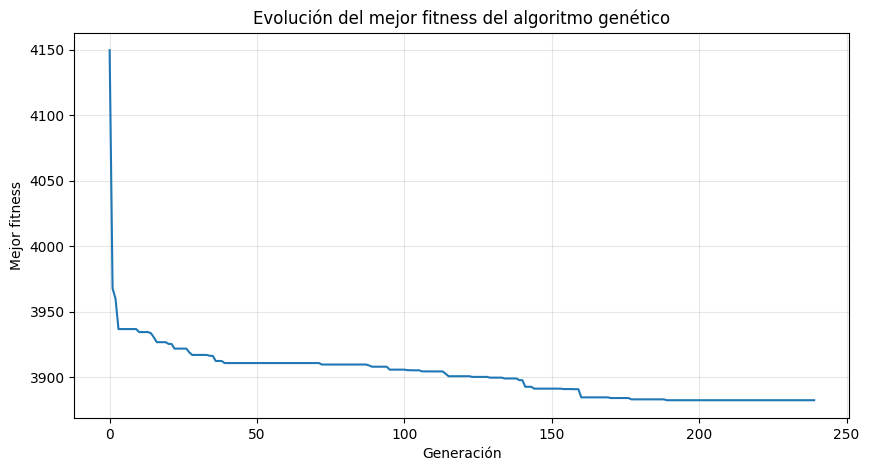

In [26]:
# ============================================================
# 20. CURVA DE CONVERGENCIA
# ============================================================

import matplotlib.pyplot as plt


plt.figure(
    figsize=(10, 5)
)

plt.plot(
    range(len(history)),
    history
)

plt.xlabel(
    "Generación"
)

plt.ylabel(
    "Mejor fitness"
)

plt.title(
    "Evolución del mejor fitness del algoritmo genético"
)

plt.grid(
    alpha=0.3
)

plt.show()

# 21. Exportación de resultados a Google Drive
Qué hace esta sección

Finalmente, exportamos las principales tablas para que puedas analizarlas en Excel e incorporarlas posteriormente al TFM.

In [27]:
# ============================================================
# 21. EXPORTACIÓN DE RESULTADOS
# ============================================================

OUTPUT_FOLDER = (
    "/content/drive/MyDrive/TFM/resultados_AG/"
)


import os

os.makedirs(
    OUTPUT_FOLDER,
    exist_ok=True
)


assignment_results_df.to_csv(
    OUTPUT_FOLDER
    + "AG_asignaciones.csv",
    index=False
)


employee_load_df.to_csv(
    OUTPUT_FOLDER
    + "AG_carga_empleados.csv",
    index=False
)


summary_df.to_csv(
    OUTPUT_FOLDER
    + "AG_resumen.csv",
    index=False
)


pd.DataFrame(
    {
        "Generation":
            range(
                len(history)
            ),

        "Best Fitness":
            history
    }
).to_csv(
    OUTPUT_FOLDER
    + "AG_convergencia.csv",
    index=False
)


print(
    "Resultados exportados en:"
)

print(
    OUTPUT_FOLDER
)

Resultados exportados en:
/content/drive/MyDrive/TFM/resultados_AG/
